In [1]:
using PyPlot, Random

In [2]:
# Nonlinearity (smooth to avoid artifacts)
σ(s) = tanh(s)
σ_der(s) = 1/(cosh(s)^2)

σ_der (generic function with 1 method)

In [3]:
function resnet_GD_step(X, Y, U, V, WE, WU, η) # U and V are size DxMxL; WE and WU are Dxdin
    (din,N) = size(X)
    D,M,L = size(U)
    P = zeros(M,N,L)   # preactivations
    Q = zeros(M,N,L)   # backward "preact"
    H = zeros(D,N,L+1) # forward pass
    B = zeros(D,N,L+1) # backward pass
    H[:,:,1] = WE*X # is a DxN matrix
    for l = 1:L # forward pass
        P[:,:,l] = U[:,:,l]'*H[:,:,l]/D
        H[:,:,l+1] = H[:,:,l] + (1/(L*M))*V[:,:,l]*σ.(P[:,:,l])
    end
    output = (1/D)*WU'*H[:,:,L+1]
    B[:,:,L+1] = WU*(output .- Y)/(N*din) # gradient of the loss multiplied by D
    loss = sum((output .- Y).^2)/(N*din)
    for l = L:-1:1 # backward pass
        Q[:,:,l] = V[:,:,l]'*B[:,:,l+1]/D
        B[:,:,l] = B[:,:,l+1] + (1/(L*M))* U[:,:,l]*(σ_der.(P[:,:,l]).*Q[:,:,l])
    end
    # compute gradients
    gradU = zeros(D,M,L)
    gradV = zeros(D,M,L)
    for l=1:L
        gradU[:,:,l] = H[:,:,l] * ( σ_der.(P[:,:,l]) .* Q[:,:,l])'
        gradV[:,:,l] = B[:,:,l+1]*(σ.(P[:,:,l])') 
    end

    # apply update (for simplicity we do not update WU, WE)
    
    U_new = U .- η*gradU 
    V_new = V .- η*gradV 
    
    return U_new, V_new, loss, output, H
    
end

resnet_GD_step (generic function with 1 method)

# Methodo

We'll do 1 experiment with 5 reps and 6 plots as outputs. We want to plot at $k=15$, the error in embedding space and in output space. We take the same data across 5 reps, but resample the embedding matrices. The time should be 5000 seconds (less than 2 hours).

In [4]:
# shapes
n_L = 1
n_M = 20
n_D = 20
n_reps = 5
# If redo: go to D=4000 and divide L by 2.
Ls = [50]
Ms = Int.(floor.(exp10.(range(log10(1.5),log10(2000),length=n_M))))
Ds = Int.(floor.(exp10.(range(log10(1.5),log10(2000),length=n_D))))
Ls, Ms, Ds #check that there's no duplicate (to not waste compute)

([50], [1, 2, 3, 4, 6, 9, 14, 21, 31, 45, 66, 96, 141, 206, 301, 439, 642, 937, 1369, 2000], [1, 2, 3, 4, 6, 9, 14, 21, 31, 45, 66, 96, 141, 206, 301, 439, 642, 937, 1369, 2000])

# One experiment with coupling

In [5]:
Random.seed!(1)

# training set
din = 5
dout = 5
N = 10
X = randn(din, N)
Y = randn(dout, N)

# GD HP
K = 15 #n_iter
η = 1  #LR

1

In [7]:
# with coupling
outputs = zeros(dout, N, n_L, n_M, n_D, K, n_reps)
loss_track = zeros(n_L, n_M, n_D, K, n_reps)
Hs_last = zeros(Ds[end], N, n_L, n_M, n_D, K, n_reps)


@time for j = 1:n_reps
    
    WE_tot = randn(Ds[end],din)/sqrt(din)
    WU_tot = randn(Ds[end],dout)*sqrt(dout)
    
    for i = 1:n_L
        for ii = 1:n_M
            for iii = 1:n_D
                @show (i,ii,iii)
                L = Ls[i]
                M = Ms[ii]
                D = Ds[iii]
            
                U = randn(D,M,L)*sqrt(D)
                V = randn(D,M,L)*sqrt(D)
                WE = WE_tot[1:D,:] # coupled randomness
                WU = WU_tot[1:D,:]
                for k = 1:K
                    U, V, loss_track[i,ii,iii,k, j], outputs[:,:,i,ii,iii,k, j], H = resnet_GD_step(X,Y,U,V,WE,WU,η) ####
                    Hs_last[1:D,:,i,ii,iii,k, j] = H[:,:,end]
                end
            end
        end
    end
end

(i, ii, iii) = (1, 1, 1)
(i, ii, iii) = (1, 1, 2)
(i, ii, iii) = (1, 1, 3)
(i, ii, iii) = (1, 1, 4)
(i, ii, iii) = (1, 1, 5)
(i, ii, iii) = (1, 1, 6)
(i, ii, iii) = (1, 1, 7)
(i, ii, iii) = (1, 1, 8)
(i, ii, iii) = (1, 1, 9)
(i, ii, iii) = (1, 1, 10)
(i, ii, iii) = (1, 1, 11)
(i, ii, iii) = (1, 1, 12)
(i, ii, iii) = (1, 1, 13)
(i, ii, iii) = (1, 1, 14)
(i, ii, iii) = (1, 1, 15)
(i, ii, iii) = (1, 1, 16)
(i, ii, iii) = (1, 1, 17)
(i, ii, iii) = (1, 1, 18)
(i, ii, iii) = (1, 1, 19)
(i, ii, iii) = (1, 1, 20)
(i, ii, iii) = (1, 2, 1)
(i, ii, iii) = (1, 2, 2)
(i, ii, iii) = (1, 2, 3)
(i, ii, iii) = (1, 2, 4)
(i, ii, iii) = (1, 2, 5)
(i, ii, iii) = (1, 2, 6)
(i, ii, iii) = (1, 2, 7)
(i, ii, iii) = (1, 2, 8)
(i, ii, iii) = (1, 2, 9)
(i, ii, iii) = (1, 2, 10)
(i, ii, iii) = (1, 2, 11)
(i, ii, iii) = (1, 2, 12)
(i, ii, iii) = (1, 2, 13)
(i, ii, iii) = (1, 2, 14)
(i, ii, iii) = (1, 2, 15)
(i, ii, iii) = (1, 2, 16)
(i, ii, iii) = (1, 2, 17)
(i, ii, iii) = (1, 2, 18)
(i, ii, iii) = (1, 2, 19)
(i, 

(i, ii, iii) = (1, 16, 16)
(i, ii, iii) = (1, 16, 17)
(i, ii, iii) = (1, 16, 18)
(i, ii, iii) = (1, 16, 19)
(i, ii, iii) = (1, 16, 20)
(i, ii, iii) = (1, 17, 1)
(i, ii, iii) = (1, 17, 2)
(i, ii, iii) = (1, 17, 3)
(i, ii, iii) = (1, 17, 4)
(i, ii, iii) = (1, 17, 5)
(i, ii, iii) = (1, 17, 6)
(i, ii, iii) = (1, 17, 7)
(i, ii, iii) = (1, 17, 8)
(i, ii, iii) = (1, 17, 9)
(i, ii, iii) = (1, 17, 10)
(i, ii, iii) = (1, 17, 11)
(i, ii, iii) = (1, 17, 12)
(i, ii, iii) = (1, 17, 13)
(i, ii, iii) = (1, 17, 14)
(i, ii, iii) = (1, 17, 15)
(i, ii, iii) = (1, 17, 16)
(i, ii, iii) = (1, 17, 17)
(i, ii, iii) = (1, 17, 18)
(i, ii, iii) = (1, 17, 19)
(i, ii, iii) = (1, 17, 20)
(i, ii, iii) = (1, 18, 1)
(i, ii, iii) = (1, 18, 2)
(i, ii, iii) = (1, 18, 3)
(i, ii, iii) = (1, 18, 4)
(i, ii, iii) = (1, 18, 5)
(i, ii, iii) = (1, 18, 6)
(i, ii, iii) = (1, 18, 7)
(i, ii, iii) = (1, 18, 8)
(i, ii, iii) = (1, 18, 9)
(i, ii, iii) = (1, 18, 10)
(i, ii, iii) = (1, 18, 11)
(i, ii, iii) = (1, 18, 12)
(i, ii, iii) = (1, 

(i, ii, iii) = (1, 12, 12)
(i, ii, iii) = (1, 12, 13)
(i, ii, iii) = (1, 12, 14)
(i, ii, iii) = (1, 12, 15)
(i, ii, iii) = (1, 12, 16)
(i, ii, iii) = (1, 12, 17)
(i, ii, iii) = (1, 12, 18)
(i, ii, iii) = (1, 12, 19)
(i, ii, iii) = (1, 12, 20)
(i, ii, iii) = (1, 13, 1)
(i, ii, iii) = (1, 13, 2)
(i, ii, iii) = (1, 13, 3)
(i, ii, iii) = (1, 13, 4)
(i, ii, iii) = (1, 13, 5)
(i, ii, iii) = (1, 13, 6)
(i, ii, iii) = (1, 13, 7)
(i, ii, iii) = (1, 13, 8)
(i, ii, iii) = (1, 13, 9)
(i, ii, iii) = (1, 13, 10)
(i, ii, iii) = (1, 13, 11)
(i, ii, iii) = (1, 13, 12)
(i, ii, iii) = (1, 13, 13)
(i, ii, iii) = (1, 13, 14)
(i, ii, iii) = (1, 13, 15)
(i, ii, iii) = (1, 13, 16)
(i, ii, iii) = (1, 13, 17)
(i, ii, iii) = (1, 13, 18)
(i, ii, iii) = (1, 13, 19)
(i, ii, iii) = (1, 13, 20)
(i, ii, iii) = (1, 14, 1)
(i, ii, iii) = (1, 14, 2)
(i, ii, iii) = (1, 14, 3)
(i, ii, iii) = (1, 14, 4)
(i, ii, iii) = (1, 14, 5)
(i, ii, iii) = (1, 14, 6)
(i, ii, iii) = (1, 14, 7)
(i, ii, iii) = (1, 14, 8)
(i, ii, iii) = (1,

(i, ii, iii) = (1, 8, 7)
(i, ii, iii) = (1, 8, 8)
(i, ii, iii) = (1, 8, 9)
(i, ii, iii) = (1, 8, 10)
(i, ii, iii) = (1, 8, 11)
(i, ii, iii) = (1, 8, 12)
(i, ii, iii) = (1, 8, 13)
(i, ii, iii) = (1, 8, 14)
(i, ii, iii) = (1, 8, 15)
(i, ii, iii) = (1, 8, 16)
(i, ii, iii) = (1, 8, 17)
(i, ii, iii) = (1, 8, 18)
(i, ii, iii) = (1, 8, 19)
(i, ii, iii) = (1, 8, 20)
(i, ii, iii) = (1, 9, 1)
(i, ii, iii) = (1, 9, 2)
(i, ii, iii) = (1, 9, 3)
(i, ii, iii) = (1, 9, 4)
(i, ii, iii) = (1, 9, 5)
(i, ii, iii) = (1, 9, 6)
(i, ii, iii) = (1, 9, 7)
(i, ii, iii) = (1, 9, 8)
(i, ii, iii) = (1, 9, 9)
(i, ii, iii) = (1, 9, 10)
(i, ii, iii) = (1, 9, 11)
(i, ii, iii) = (1, 9, 12)
(i, ii, iii) = (1, 9, 13)
(i, ii, iii) = (1, 9, 14)
(i, ii, iii) = (1, 9, 15)
(i, ii, iii) = (1, 9, 16)
(i, ii, iii) = (1, 9, 17)
(i, ii, iii) = (1, 9, 18)
(i, ii, iii) = (1, 9, 19)
(i, ii, iii) = (1, 9, 20)
(i, ii, iii) = (1, 10, 1)
(i, ii, iii) = (1, 10, 2)
(i, ii, iii) = (1, 10, 3)
(i, ii, iii) = (1, 10, 4)
(i, ii, iii) = (1, 10, 5

(i, ii, iii) = (1, 3, 19)
(i, ii, iii) = (1, 3, 20)
(i, ii, iii) = (1, 4, 1)
(i, ii, iii) = (1, 4, 2)
(i, ii, iii) = (1, 4, 3)
(i, ii, iii) = (1, 4, 4)
(i, ii, iii) = (1, 4, 5)
(i, ii, iii) = (1, 4, 6)
(i, ii, iii) = (1, 4, 7)
(i, ii, iii) = (1, 4, 8)
(i, ii, iii) = (1, 4, 9)
(i, ii, iii) = (1, 4, 10)
(i, ii, iii) = (1, 4, 11)
(i, ii, iii) = (1, 4, 12)
(i, ii, iii) = (1, 4, 13)
(i, ii, iii) = (1, 4, 14)
(i, ii, iii) = (1, 4, 15)
(i, ii, iii) = (1, 4, 16)
(i, ii, iii) = (1, 4, 17)
(i, ii, iii) = (1, 4, 18)
(i, ii, iii) = (1, 4, 19)
(i, ii, iii) = (1, 4, 20)
(i, ii, iii) = (1, 5, 1)
(i, ii, iii) = (1, 5, 2)
(i, ii, iii) = (1, 5, 3)
(i, ii, iii) = (1, 5, 4)
(i, ii, iii) = (1, 5, 5)
(i, ii, iii) = (1, 5, 6)
(i, ii, iii) = (1, 5, 7)
(i, ii, iii) = (1, 5, 8)
(i, ii, iii) = (1, 5, 9)
(i, ii, iii) = (1, 5, 10)
(i, ii, iii) = (1, 5, 11)
(i, ii, iii) = (1, 5, 12)
(i, ii, iii) = (1, 5, 13)
(i, ii, iii) = (1, 5, 14)
(i, ii, iii) = (1, 5, 15)
(i, ii, iii) = (1, 5, 16)
(i, ii, iii) = (1, 5, 17)
(i, 

(i, ii, iii) = (1, 19, 12)
(i, ii, iii) = (1, 19, 13)
(i, ii, iii) = (1, 19, 14)
(i, ii, iii) = (1, 19, 15)
(i, ii, iii) = (1, 19, 16)
(i, ii, iii) = (1, 19, 17)
(i, ii, iii) = (1, 19, 18)
(i, ii, iii) = (1, 19, 19)
(i, ii, iii) = (1, 19, 20)
(i, ii, iii) = (1, 20, 1)
(i, ii, iii) = (1, 20, 2)
(i, ii, iii) = (1, 20, 3)
(i, ii, iii) = (1, 20, 4)
(i, ii, iii) = (1, 20, 5)
(i, ii, iii) = (1, 20, 6)
(i, ii, iii) = (1, 20, 7)
(i, ii, iii) = (1, 20, 8)
(i, ii, iii) = (1, 20, 9)
(i, ii, iii) = (1, 20, 10)
(i, ii, iii) = (1, 20, 11)
(i, ii, iii) = (1, 20, 12)
(i, ii, iii) = (1, 20, 13)
(i, ii, iii) = (1, 20, 14)
(i, ii, iii) = (1, 20, 15)
(i, ii, iii) = (1, 20, 16)
(i, ii, iii) = (1, 20, 17)
(i, ii, iii) = (1, 20, 18)
(i, ii, iii) = (1, 20, 19)
(i, ii, iii) = (1, 20, 20)
(i, ii, iii) = (1, 1, 1)
(i, ii, iii) = (1, 1, 2)
(i, ii, iii) = (1, 1, 3)
(i, ii, iii) = (1, 1, 4)
(i, ii, iii) = (1, 1, 5)
(i, ii, iii) = (1, 1, 6)
(i, ii, iii) = (1, 1, 7)
(i, ii, iii) = (1, 1, 8)
(i, ii, iii) = (1, 1, 9)
(

(i, ii, iii) = (1, 15, 8)
(i, ii, iii) = (1, 15, 9)
(i, ii, iii) = (1, 15, 10)
(i, ii, iii) = (1, 15, 11)
(i, ii, iii) = (1, 15, 12)
(i, ii, iii) = (1, 15, 13)
(i, ii, iii) = (1, 15, 14)
(i, ii, iii) = (1, 15, 15)
(i, ii, iii) = (1, 15, 16)
(i, ii, iii) = (1, 15, 17)
(i, ii, iii) = (1, 15, 18)
(i, ii, iii) = (1, 15, 19)
(i, ii, iii) = (1, 15, 20)
(i, ii, iii) = (1, 16, 1)
(i, ii, iii) = (1, 16, 2)
(i, ii, iii) = (1, 16, 3)
(i, ii, iii) = (1, 16, 4)
(i, ii, iii) = (1, 16, 5)
(i, ii, iii) = (1, 16, 6)
(i, ii, iii) = (1, 16, 7)
(i, ii, iii) = (1, 16, 8)
(i, ii, iii) = (1, 16, 9)
(i, ii, iii) = (1, 16, 10)
(i, ii, iii) = (1, 16, 11)
(i, ii, iii) = (1, 16, 12)
(i, ii, iii) = (1, 16, 13)
(i, ii, iii) = (1, 16, 14)
(i, ii, iii) = (1, 16, 15)
(i, ii, iii) = (1, 16, 16)
(i, ii, iii) = (1, 16, 17)
(i, ii, iii) = (1, 16, 18)
(i, ii, iii) = (1, 16, 19)
(i, ii, iii) = (1, 16, 20)
(i, ii, iii) = (1, 17, 1)
(i, ii, iii) = (1, 17, 2)
(i, ii, iii) = (1, 17, 3)
(i, ii, iii) = (1, 17, 4)
(i, ii, iii) = (

In [12]:
errs_y = zeros(n_L, n_M, n_D, K) # errors on output
#average the square errors over dimensions and over reps
for i = 1:n_L
    for ii = 1:n_M
        for iii = 1:n_D
            for k = 1:K
                errs_y[i,ii,iii,k] = sqrt(sum((outputs[:,:,i,ii,iii,k,:] .- outputs[:,:,end,end,end,k,:]).^2)/(dout*N*n_reps))
            end
        end
    end
end

errs_h = zeros(n_L, n_M, n_D, K) # errors on pre-unembedding vectors
#average the square errors over dimensions and over reps
for i = 1:n_L
    for ii = 1:n_M
        for iii = 1:n_D
            for k = 1:K
                D= Ds[iii]
                errs_h[i,ii,iii,k] = sqrt(sum((Hs_last[1:D,:,i,ii,iii,k,:] .- Hs_last[1:D,:,end,end,end,k,:]).^2)/(D*N*n_reps))
            end
        end
    end
end


# The same experiment without coupling (then no need to measure h)

In [ ]:
Random.seed!(1)

# training set
din = 5
dout = 5
N = 10
X = randn(din, N)
Y = randn(dout, N)

# GD HP
K = 15 #n_iter
η = 1  #LR

In [76]:
# with coupling
outputs2 = zeros(dout, N, n_L, n_M, n_D, K, n_reps)
loss_track2 = zeros(n_L, n_M, n_D, K, n_reps)
#Hs_last = zeros(Ds[end], N, n_L, n_M, n_D, K, n_reps)


@time for j = 1:n_reps
    for i = 1:n_L
        for ii = 1:n_M
            for iii = 1:n_D
                @show (i,ii,iii)
                L = Ls[i]
                M = Ms[ii]
                D = Ds[iii]
            
                U = randn(D,M,L)*sqrt(D)
                V = randn(D,M,L)*sqrt(D)
                WE = randn(D,din)/sqrt(din) # coupled randomness
                WU = randn(D,dout)*sqrt(dout)
                for k = 1:K
                    U, V, loss_track2[i,ii,iii,k, j], outputs2[:,:,i,ii,iii,k, j], H = resnet_GD_step(X,Y,U,V,WE,WU,η) ####
                end
            end
        end
    end
end

(i, ii, iii) = (1, 1, 1)
(i, ii, iii) = (1, 1, 2)
(i, ii, iii) = (1, 1, 3)
(i, ii, iii) = (1, 1, 4)
(i, ii, iii) = (1, 1, 5)
(i, ii, iii) = (1, 1, 6)
(i, ii, iii) = (1, 1, 7)
(i, ii, iii) = (1, 1, 8)
(i, ii, iii) = (1, 1, 9)
(i, ii, iii) = (1, 1, 10)
(i, ii, iii) = (1, 1, 11)
(i, ii, iii) = (1, 1, 12)
(i, ii, iii) = (1, 1, 13)
(i, ii, iii) = (1, 1, 14)
(i, ii, iii) = (1, 1, 15)
(i, ii, iii) = (1, 1, 16)
(i, ii, iii) = (1, 1, 17)
(i, ii, iii) = (1, 1, 18)
(i, ii, iii) = (1, 1, 19)
(i, ii, iii) = (1, 1, 20)
(i, ii, iii) = (1, 2, 1)
(i, ii, iii) = (1, 2, 2)
(i, ii, iii) = (1, 2, 3)
(i, ii, iii) = (1, 2, 4)
(i, ii, iii) = (1, 2, 5)
(i, ii, iii) = (1, 2, 6)
(i, ii, iii) = (1, 2, 7)
(i, ii, iii) = (1, 2, 8)
(i, ii, iii) = (1, 2, 9)
(i, ii, iii) = (1, 2, 10)
(i, ii, iii) = (1, 2, 11)
(i, ii, iii) = (1, 2, 12)
(i, ii, iii) = (1, 2, 13)
(i, ii, iii) = (1, 2, 14)
(i, ii, iii) = (1, 2, 15)
(i, ii, iii) = (1, 2, 16)
(i, ii, iii) = (1, 2, 17)
(i, ii, iii) = (1, 2, 18)
(i, ii, iii) = (1, 2, 19)
(i, 

(i, ii, iii) = (1, 16, 16)
(i, ii, iii) = (1, 16, 17)
(i, ii, iii) = (1, 16, 18)
(i, ii, iii) = (1, 16, 19)
(i, ii, iii) = (1, 16, 20)
(i, ii, iii) = (1, 17, 1)
(i, ii, iii) = (1, 17, 2)
(i, ii, iii) = (1, 17, 3)
(i, ii, iii) = (1, 17, 4)
(i, ii, iii) = (1, 17, 5)
(i, ii, iii) = (1, 17, 6)
(i, ii, iii) = (1, 17, 7)
(i, ii, iii) = (1, 17, 8)
(i, ii, iii) = (1, 17, 9)
(i, ii, iii) = (1, 17, 10)
(i, ii, iii) = (1, 17, 11)
(i, ii, iii) = (1, 17, 12)
(i, ii, iii) = (1, 17, 13)
(i, ii, iii) = (1, 17, 14)
(i, ii, iii) = (1, 17, 15)
(i, ii, iii) = (1, 17, 16)
(i, ii, iii) = (1, 17, 17)
(i, ii, iii) = (1, 17, 18)
(i, ii, iii) = (1, 17, 19)
(i, ii, iii) = (1, 17, 20)
(i, ii, iii) = (1, 18, 1)
(i, ii, iii) = (1, 18, 2)
(i, ii, iii) = (1, 18, 3)
(i, ii, iii) = (1, 18, 4)
(i, ii, iii) = (1, 18, 5)
(i, ii, iii) = (1, 18, 6)
(i, ii, iii) = (1, 18, 7)
(i, ii, iii) = (1, 18, 8)
(i, ii, iii) = (1, 18, 9)
(i, ii, iii) = (1, 18, 10)
(i, ii, iii) = (1, 18, 11)
(i, ii, iii) = (1, 18, 12)
(i, ii, iii) = (1, 

(i, ii, iii) = (1, 12, 12)
(i, ii, iii) = (1, 12, 13)
(i, ii, iii) = (1, 12, 14)
(i, ii, iii) = (1, 12, 15)
(i, ii, iii) = (1, 12, 16)
(i, ii, iii) = (1, 12, 17)
(i, ii, iii) = (1, 12, 18)
(i, ii, iii) = (1, 12, 19)
(i, ii, iii) = (1, 12, 20)
(i, ii, iii) = (1, 13, 1)
(i, ii, iii) = (1, 13, 2)
(i, ii, iii) = (1, 13, 3)
(i, ii, iii) = (1, 13, 4)
(i, ii, iii) = (1, 13, 5)
(i, ii, iii) = (1, 13, 6)
(i, ii, iii) = (1, 13, 7)
(i, ii, iii) = (1, 13, 8)
(i, ii, iii) = (1, 13, 9)
(i, ii, iii) = (1, 13, 10)
(i, ii, iii) = (1, 13, 11)
(i, ii, iii) = (1, 13, 12)
(i, ii, iii) = (1, 13, 13)
(i, ii, iii) = (1, 13, 14)
(i, ii, iii) = (1, 13, 15)
(i, ii, iii) = (1, 13, 16)
(i, ii, iii) = (1, 13, 17)
(i, ii, iii) = (1, 13, 18)
(i, ii, iii) = (1, 13, 19)
(i, ii, iii) = (1, 13, 20)
(i, ii, iii) = (1, 14, 1)
(i, ii, iii) = (1, 14, 2)
(i, ii, iii) = (1, 14, 3)
(i, ii, iii) = (1, 14, 4)
(i, ii, iii) = (1, 14, 5)
(i, ii, iii) = (1, 14, 6)
(i, ii, iii) = (1, 14, 7)
(i, ii, iii) = (1, 14, 8)
(i, ii, iii) = (1,

(i, ii, iii) = (1, 8, 9)
(i, ii, iii) = (1, 8, 10)
(i, ii, iii) = (1, 8, 11)
(i, ii, iii) = (1, 8, 12)
(i, ii, iii) = (1, 8, 13)
(i, ii, iii) = (1, 8, 14)
(i, ii, iii) = (1, 8, 15)
(i, ii, iii) = (1, 8, 16)
(i, ii, iii) = (1, 8, 17)
(i, ii, iii) = (1, 8, 18)
(i, ii, iii) = (1, 8, 19)
(i, ii, iii) = (1, 8, 20)
(i, ii, iii) = (1, 9, 1)
(i, ii, iii) = (1, 9, 2)
(i, ii, iii) = (1, 9, 3)
(i, ii, iii) = (1, 9, 4)
(i, ii, iii) = (1, 9, 5)
(i, ii, iii) = (1, 9, 6)
(i, ii, iii) = (1, 9, 7)
(i, ii, iii) = (1, 9, 8)
(i, ii, iii) = (1, 9, 9)
(i, ii, iii) = (1, 9, 10)
(i, ii, iii) = (1, 9, 11)
(i, ii, iii) = (1, 9, 12)
(i, ii, iii) = (1, 9, 13)
(i, ii, iii) = (1, 9, 14)
(i, ii, iii) = (1, 9, 15)
(i, ii, iii) = (1, 9, 16)
(i, ii, iii) = (1, 9, 17)
(i, ii, iii) = (1, 9, 18)
(i, ii, iii) = (1, 9, 19)
(i, ii, iii) = (1, 9, 20)
(i, ii, iii) = (1, 10, 1)
(i, ii, iii) = (1, 10, 2)
(i, ii, iii) = (1, 10, 3)
(i, ii, iii) = (1, 10, 4)
(i, ii, iii) = (1, 10, 5)
(i, ii, iii) = (1, 10, 6)
(i, ii, iii) = (1, 10,

(i, ii, iii) = (1, 4, 1)
(i, ii, iii) = (1, 4, 2)
(i, ii, iii) = (1, 4, 3)
(i, ii, iii) = (1, 4, 4)
(i, ii, iii) = (1, 4, 5)
(i, ii, iii) = (1, 4, 6)
(i, ii, iii) = (1, 4, 7)
(i, ii, iii) = (1, 4, 8)
(i, ii, iii) = (1, 4, 9)
(i, ii, iii) = (1, 4, 10)
(i, ii, iii) = (1, 4, 11)
(i, ii, iii) = (1, 4, 12)
(i, ii, iii) = (1, 4, 13)
(i, ii, iii) = (1, 4, 14)
(i, ii, iii) = (1, 4, 15)
(i, ii, iii) = (1, 4, 16)
(i, ii, iii) = (1, 4, 17)
(i, ii, iii) = (1, 4, 18)
(i, ii, iii) = (1, 4, 19)
(i, ii, iii) = (1, 4, 20)
(i, ii, iii) = (1, 5, 1)
(i, ii, iii) = (1, 5, 2)
(i, ii, iii) = (1, 5, 3)
(i, ii, iii) = (1, 5, 4)
(i, ii, iii) = (1, 5, 5)
(i, ii, iii) = (1, 5, 6)
(i, ii, iii) = (1, 5, 7)
(i, ii, iii) = (1, 5, 8)
(i, ii, iii) = (1, 5, 9)
(i, ii, iii) = (1, 5, 10)
(i, ii, iii) = (1, 5, 11)
(i, ii, iii) = (1, 5, 12)
(i, ii, iii) = (1, 5, 13)
(i, ii, iii) = (1, 5, 14)
(i, ii, iii) = (1, 5, 15)
(i, ii, iii) = (1, 5, 16)
(i, ii, iii) = (1, 5, 17)
(i, ii, iii) = (1, 5, 18)
(i, ii, iii) = (1, 5, 19)
(i, 

(i, ii, iii) = (1, 19, 14)
(i, ii, iii) = (1, 19, 15)
(i, ii, iii) = (1, 19, 16)
(i, ii, iii) = (1, 19, 17)
(i, ii, iii) = (1, 19, 18)
(i, ii, iii) = (1, 19, 19)
(i, ii, iii) = (1, 19, 20)
(i, ii, iii) = (1, 20, 1)
(i, ii, iii) = (1, 20, 2)
(i, ii, iii) = (1, 20, 3)
(i, ii, iii) = (1, 20, 4)
(i, ii, iii) = (1, 20, 5)
(i, ii, iii) = (1, 20, 6)
(i, ii, iii) = (1, 20, 7)
(i, ii, iii) = (1, 20, 8)
(i, ii, iii) = (1, 20, 9)
(i, ii, iii) = (1, 20, 10)
(i, ii, iii) = (1, 20, 11)
(i, ii, iii) = (1, 20, 12)
(i, ii, iii) = (1, 20, 13)
(i, ii, iii) = (1, 20, 14)
(i, ii, iii) = (1, 20, 15)
(i, ii, iii) = (1, 20, 16)
(i, ii, iii) = (1, 20, 17)
(i, ii, iii) = (1, 20, 18)
(i, ii, iii) = (1, 20, 19)
(i, ii, iii) = (1, 20, 20)
(i, ii, iii) = (1, 1, 1)
(i, ii, iii) = (1, 1, 2)
(i, ii, iii) = (1, 1, 3)
(i, ii, iii) = (1, 1, 4)
(i, ii, iii) = (1, 1, 5)
(i, ii, iii) = (1, 1, 6)
(i, ii, iii) = (1, 1, 7)
(i, ii, iii) = (1, 1, 8)
(i, ii, iii) = (1, 1, 9)
(i, ii, iii) = (1, 1, 10)
(i, ii, iii) = (1, 1, 11)
(i,

(i, ii, iii) = (1, 15, 10)
(i, ii, iii) = (1, 15, 11)
(i, ii, iii) = (1, 15, 12)
(i, ii, iii) = (1, 15, 13)
(i, ii, iii) = (1, 15, 14)
(i, ii, iii) = (1, 15, 15)
(i, ii, iii) = (1, 15, 16)
(i, ii, iii) = (1, 15, 17)
(i, ii, iii) = (1, 15, 18)
(i, ii, iii) = (1, 15, 19)
(i, ii, iii) = (1, 15, 20)
(i, ii, iii) = (1, 16, 1)
(i, ii, iii) = (1, 16, 2)
(i, ii, iii) = (1, 16, 3)
(i, ii, iii) = (1, 16, 4)
(i, ii, iii) = (1, 16, 5)
(i, ii, iii) = (1, 16, 6)
(i, ii, iii) = (1, 16, 7)
(i, ii, iii) = (1, 16, 8)
(i, ii, iii) = (1, 16, 9)
(i, ii, iii) = (1, 16, 10)
(i, ii, iii) = (1, 16, 11)
(i, ii, iii) = (1, 16, 12)
(i, ii, iii) = (1, 16, 13)
(i, ii, iii) = (1, 16, 14)
(i, ii, iii) = (1, 16, 15)
(i, ii, iii) = (1, 16, 16)
(i, ii, iii) = (1, 16, 17)
(i, ii, iii) = (1, 16, 18)
(i, ii, iii) = (1, 16, 19)
(i, ii, iii) = (1, 16, 20)
(i, ii, iii) = (1, 17, 1)
(i, ii, iii) = (1, 17, 2)
(i, ii, iii) = (1, 17, 3)
(i, ii, iii) = (1, 17, 4)
(i, ii, iii) = (1, 17, 5)
(i, ii, iii) = (1, 17, 6)
(i, ii, iii) = (

In [77]:
errs_y2 = zeros(n_L, n_M, n_D, K) # errors on output
#average the square errors over dimensions and over reps
for i = 1:n_L
    for ii = 1:n_M
        for iii = 1:n_D
            for k = 1:K
                errs_y2[i,ii,iii,k] = sqrt(sum((outputs2[:,:,i,ii,iii,k,:] .- outputs2[:,:,end,end,end,k,:]).^2)/(dout*N*n_reps))
            end
        end
    end
end


# Now plot results

We start with the plots for the output

In [110]:
pp = 2
fit_y(L,M,D) = ( (0.15*(D/(M*L))).^pp + (0.9/sqrt(D)).^pp)^(1/pp)

fit_y (generic function with 1 method)

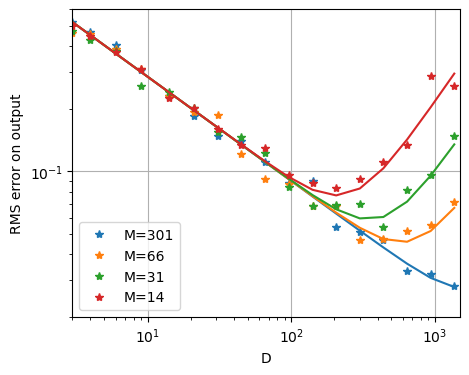

In [225]:
k = 15
figure(figsize=[5,4])
loglog(Ds[1:end-1],errs_y2[end,end-5,1:end-1,k]',"*C0",label="M=$(Ms[end-5])")
loglog(Ds[1:end-1],fit_y.(Ls[end],Ms[end-5],Ds[1:end-1]),"C0")

loglog(Ds[1:end-1],errs_y2[end,end-9,1:end-1,k]',"*C1",label="M=$(Ms[end-9])")
loglog(Ds[1:end-1],fit_y.(Ls[end],Ms[end-9],Ds[1:end-1]),"C1")

loglog(Ds[1:end-1],errs_y2[end,end-11,1:end-1,k]',"*C2",label="M=$(Ms[end-11])")
loglog(Ds[1:end-1],fit_y.(Ls[end],Ms[end-11],Ds[1:end-1]),"C2")

loglog(Ds[1:end-1],errs_y2[end,end-13,1:end-1,k]',"*C3",label="M=$(Ms[end-13])")
loglog(Ds[1:end-1],fit_y.(Ls[end],Ms[end-13],Ds[1:end-1]),"C3")
grid("on")
xlabel("D")
ylabel("RMS error on output")
legend()

axis([3,1500,2e-2,6e-1])
#savefig("erry_vs_D.pdf",bbox_inches="tight")

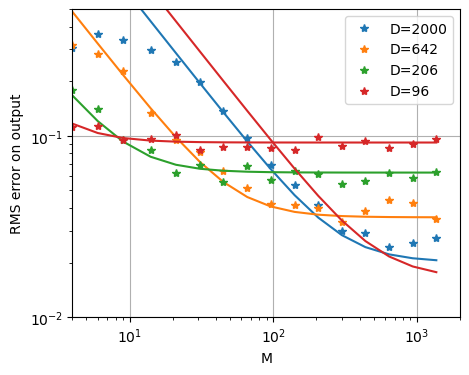

(4.0, 2000.0, 0.01, 0.5)

In [240]:
figure(figsize=[5,4])
loglog(Ms[1:end-1],errs_y2[end,1:end-1,end,k]',"*C0",label="D=$(Ds[end])")
loglog(Ms[1:end-1],fit_y.(Ls[end],Ms[1:end-1],Ds[end]),"C0")
#loglog(Ms[1:end-1],1 ./ Ms[1:end-1],"C0")

loglog(Ms[1:end-1],errs_y2[end,1:end-1,end-3,k]',"*C1",label="D=$(Ds[end-3])")
loglog(Ms[1:end-1],fit_y.(Ls[end],Ms[1:end-1],Ds[end-3]),"C1")

loglog(Ms[1:end-1],errs_y2[end,1:end-1,end-6,k]',"*C2",label="D=$(Ds[end-6])")
loglog(Ms[1:end-1],fit_y.(Ls[end],Ms[1:end-1],Ds[end-6]),"C2")

loglog(Ms[1:end-1],errs_y2[end,1:end-1,end-8,k]',"*C3",label="D=$(Ds[end-8])")
loglog(Ms[1:end-1],fit_y.(Ls[end],Ms[1:end-1],Ds[end-8]),"C3")
#loglog(Ms[1:end-1],1 ./ Ms[1:end-1],"k--")
#loglog(Ms[1:end-1],1 ./ sqrt.(Ms[1:end-1]),"k--")
#loglog(Ms[1:end-1],fit_y.(Ls[end],Ms[1:end-1],3000),"C3")


#loglog(Ms[1:end-1],errs[end-8,1:end-1,end-5,10]',"*C4")
#loglog(Ms[1:end-1],fit.(Ls[end-8],Ms[1:end-1],Ds[end-5]),"C4")
grid("on")
xlabel("M")
ylabel("RMS error on output")
legend()
axis([4,2e3,1e-2,5e-1])
#savefig("erry_vs_M.pdf",bbox_inches="tight")


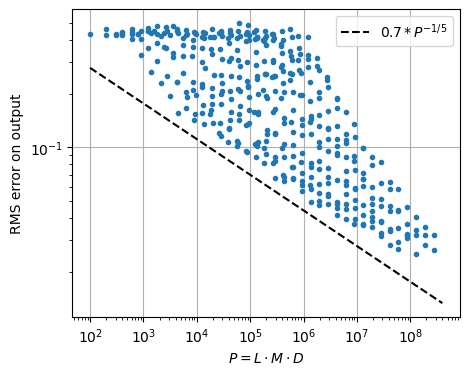

PyObject Text(24.000000000000007, 0.5, 'RMS error on output')

In [274]:
figure(figsize=[5,4])
#loglog(Ls[1]*Ms[1]*Ds[1], errs[1,1,1,10])
Ps = [2*Ls[i]*Ms[ii]*Ds[iii] for i=1:length(Ls), ii=1:length(Ms), iii=1:length(Ds)]
loglog(Ps[:], errs_y2[:,:,:,10][:],".")
#loglog(Ps[:],0.4*Ps[:].^(-1/6),"k",alpha=0.3)
loglog(Ps[:],0.7*Ps[:].^(-1/5),"--k",label=L"0.7*P^{-1/5}")
#loglog(Ps[:],Ps[:].^(-1/4),"k",alpha=0.3)
grid("on")
legend()
xlabel(L"P=L\cdot M\cdot D")
ylabel("RMS error on output")
#savefig("erry_vs_P.pdf",bbox_inches="tight")

Now do the plots with the output of embedding space

In [228]:
pp = 2
fit_h(L,M,D) = ( (0.8*sqrt(D/(M*L))).^pp + (2.5/sqrt(D)).^pp)^(1/pp)

fit_h (generic function with 1 method)

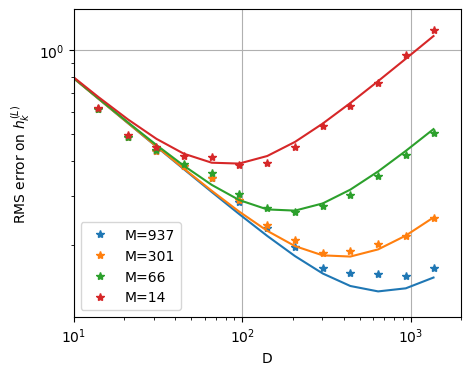

In [272]:
k = 15
figure(figsize=[5,4])
loglog(Ds[1:end-1],errs_h[end,end-2,1:end-1,k]',"*C0",label="M=$(Ms[end-2])")
loglog(Ds[1:end-1],fit_h.(Ls[end],Ms[end-2],Ds[1:end-1]),"C0")

loglog(Ds[1:end-1],errs_h[end,end-5,1:end-1,k]',"*C1",label="M=$(Ms[end-5])")
loglog(Ds[1:end-1],fit_h.(Ls[end],Ms[end-5],Ds[1:end-1]),"C1")

loglog(Ds[1:end-1],errs_h[end,end-9,1:end-1,k]',"*C2",label="M=$(Ms[end-9])")
loglog(Ds[1:end-1],fit_h.(Ls[end],Ms[end-9],Ds[1:end-1]),"C2")

loglog(Ds[1:end-1],errs_h[end,end-13,1:end-1,k]',"*C3",label="M=$(Ms[end-13])")
loglog(Ds[1:end-1],fit_h.(Ls[end],Ms[end-13],Ds[1:end-1]),"C3")
grid("on")
xlabel("D")
ylabel(L"RMS error on $h^{(L)}_k$")
legend()

axis([10,2000,1.1e-1,1.4e0])
#savefig("errh_vs_D.pdf",bbox_inches="tight")

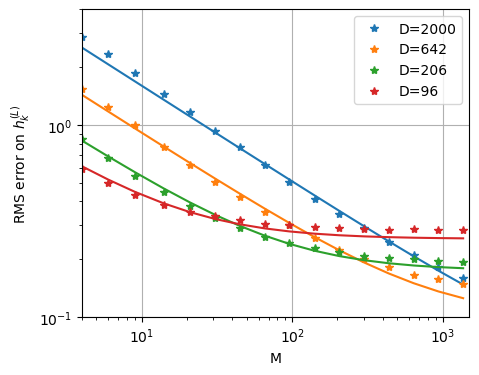

In [271]:
figure(figsize=[5,4])
loglog(Ms[1:end-1],errs_h[end,1:end-1,end,k]',"*C0",label="D=$(Ds[end])")
loglog(Ms[1:end-1],fit_h.(Ls[end],Ms[1:end-1],Ds[end]),"C0")
#loglog(Ms[1:end-1],1 ./ Ms[1:end-1],"C0")

loglog(Ms[1:end-1],errs_h[end,1:end-1,end-3,k]',"*C1",label="D=$(Ds[end-3])")
loglog(Ms[1:end-1],fit_h.(Ls[end],Ms[1:end-1],Ds[end-3]),"C1")

loglog(Ms[1:end-1],errs_h[end,1:end-1,end-6,k]',"*C2",label="D=$(Ds[end-6])")
loglog(Ms[1:end-1],fit_h.(Ls[end],Ms[1:end-1],Ds[end-6]),"C2")

loglog(Ms[1:end-1],errs_h[end,1:end-1,end-8,k]',"*C3",label="D=$(Ds[end-8])")
loglog(Ms[1:end-1],fit_h.(Ls[end],Ms[1:end-1],Ds[end-8]),"C3")



#loglog(Ms[1:end-1],errs[end-8,1:end-1,end-5,10]',"*C4")
#loglog(Ms[1:end-1],fit.(Ls[end-8],Ms[1:end-1],Ds[end-5]),"C4")
grid("on")
xlabel("M")
ylabel(L"RMS error on $h^{(L)}_k$")
legend()
axis([4,1.5e3,1e-1,4e0])
#savefig("errh_vs_M.pdf",bbox_inches="tight")

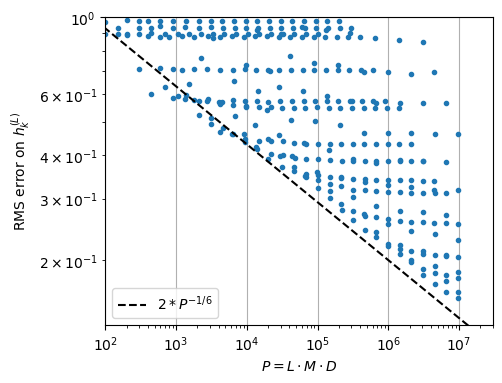

(100.0, 3.0e7, 0.13, 1.0)

In [290]:
figure(figsize=[5,4])
#loglog(Ls[1]*Ms[1]*Ds[1], errs[1,1,1,10])
Ps = [Ls[i]*Ms[ii]*Ds[iii] for i=1:length(Ls), ii=1:length(Ms), iii=1:length(Ds)]
loglog(Ps[Ps .< 1e7], errs_h[:,:,:,10][Ps .< 1e7],".")
loglog([1, 5e7],2.0*[1, 5e7].^(-1/6),"--k",label=L"2*P^{-1/6}")
#loglog(Ps[:],1.5*Ps[:].^(-1/7),"--k",label=L"1.5*P^{-1/7}")
#loglog(Ps[:],2.3*Ps[:].^(-1/5),"k",alpha=0.3)
#loglog(Ps[:],2.3*Ps[:].^(-1/4),"k",alpha=0.3)
grid("on")
legend()
xlabel(L"P=L\cdot M\cdot D")
ylabel(L"RMS error on $h^{(L)}_k$")
axis([1e2,3e7, 0.13,1])
#savefig("errh_vs_P.pdf",bbox_inches="tight")


### What is below was not used in the final figures of the paper and might not compile

### Reference run (large scale)

In [ ]:
K = 50 # nb of GD steps
output_lim = zeros(din,N,K,2)
Plim = 2e8

D = Int(floor(Dref*(Plim/Pref)^(1/3)))
M = Int(floor(Mref*(Plim/Pref)^((1/3))))
L = Int(floor(Plim /(M*D))) # ensures MLD \approx P
@show (M*L*D,  Plim)

(α,η)= (1,1)
(ηu,ηv) = (D,D)
loss_track=zeros(K)

U = randn(D,M,L)*sqrt(D)
V = randn(D,M,L)*sqrt(D)
WE = randn(D,din)/sqrt(din)
WU = randn(D,din)*sqrt(din)/D

for k = 1:K
    @show k
    U, V, loss_track[k], output_lim[:,:,k,1] = resnet_GD_step(X,Y,U,V,WE,WU,α,η, ηu=ηu,ηv=ηv) ####
end

U = randn(D,M,L)*sqrt(D)
V = randn(D,M,L)*sqrt(D)
WE = randn(D,din)/sqrt(din)
WU = randn(D,din)*sqrt(din)/D

for k = 1:K
    @show k
    U, V, loss_track[k], output_lim[:,:,k,2] = resnet_GD_step(X,Y,U,V,WE,WU,α,η, ηu=ηu,ηv=ηv) ####
end

## Runs with increasing size

In [ ]:
K = 50 # nb of GD steps
outputs = zeros(din,N,K,length(Ps),length(exponents))
errs = zeros(length(Ps),length(exponents))
@time for i = 1:length(exponents)
    for j = 1:length(Ps)
        @show (i,j)
D = Int(floor(Dref*(Ps[j]/Pref)^(exponents[i])))
M = Int(floor(Mref*(Ps[j]/Pref)^((1-exponents[i])/2)))
L = Int(floor(Ps[j] /(M*D))) # ensures MLD \approx P
 (M*L*D,  Ps[j])
U = randn(D,M,L)*sqrt(D)
V = randn(D,M,L)*sqrt(D)
WE = randn(D,din)/sqrt(din)
WU = randn(D,din)*sqrt(din)/D

(α,η)= (1,1)
(ηu,ηv) = (D,D)
loss_track=zeros(K)

    for k = 1:K
        U, V, loss_track[k], outputs[:,:,k,j,i] = resnet_GD_step(X,Y,U,V,WE,WU,α,η, ηu=ηu,ηv=ηv) ####
    end
   #     errs[j,i] = sqrt(sum((output_lim[:,:,K] .- outputs[:,:,K,j,i]).^2)/(N*din))
    end
end

## Compute errors

In [ ]:
kk = 15
for i = 1:length(exponents)
    for j = 1:length(Ps)
        errs[j,i] = sqrt(sum((output_lim[:,:,kk,1] .- outputs[:,:,kk,j,i]).^2)/(N*din))
    end
end

## Video output

In [ ]:
for kk=1:50
    figure(figsize=[6,4])
#kk = 15
for i = 1:length(exponents)
    for j = 1:length(Ps)
        errs[j,i] = sqrt(sum((output_lim[:,:,kk,2] .- outputs[:,:,kk,j,i]).^2)/(N*din))
    end
end

loglog(Ps,errs[:,1] ,"xC0",label=L"D=P^{1/4}",ms=4)
loglog(Ps,errs[:,2] ,"xC1",label=L"D=P^{1/3}",ms=4)
loglog(Ps,errs[:,3] ,"xC2",label=L"D=P^{5/12}",ms=4)
loglog(Ps,errs[:,4] ,"xC3",label=L"D=P^{1/2}",ms=4)
#loglog(Ps, 1.5*Ps.^(-1/6) ,"C1")
#loglog(Ps, 0.22*Ps.^(-1/12) ,"C2")
axis([5e2 ,2e8 ,1e-2 ,3])
grid("on")
legend(loc=1)
    xlabel(L"Nb param $P=LMD$")
    ylabel("RMS error on output")
savefig("output/infite_resnet_rates_k$(kk).png",bbox_inches="tight",dpi=150)
    close()
end

## Plot output

In [ ]:
    figure(figsize=[6,4])
kk = 10
for i = 1:length(exponents)
    for j = 1:length(Ps)
        errs[j,i] = sqrt(sum((output_lim[:,:,kk,2] .- outputs[:,:,kk,j,i]).^2)/(N*din))
    end
end

loglog(Ps,errs[:,1] ,"xC0",label=L"D=P^{1/4}",ms=4)
loglog(Ps,errs[:,2] ,"xC1",label=L"D=P^{1/3}",ms=4)
loglog(Ps,errs[:,3] ,"xC2",label=L"D=P^{5/12}",ms=4)
loglog(Ps,errs[:,4] ,"xC3",label=L"D=P^{1/2}",ms=4)
fac = 10
loglog(fac*Ps , 1.6*(fac*Ps).^(-1/8) ,"C0",label=L"P^{-1/8}")
loglog(fac*Ps , 1.65*(fac*Ps).^(-1/6) ,"C1",label=L"P^{-1/6}")
loglog(fac*Ps[div(end,3):end], 0.29*(fac*Ps[div(end,3):end]).^(-1/12) ,"C2",label=L"P^{-1/12}")
loglog(fac*Ps[div(end,3):end], 0.0*(fac*Ps[div(end,3):end]).^(-1/12) .+ 0.095 ,"C3",label=L"P^{0}")
#loglog(Ps, 1.5*Ps.^(-1/6) ,"C1")
#loglog(Ps, 0.22*Ps.^(-1/12) ,"C2")
axis([5e2 ,5e8 ,5e-2 ,1.1])
grid("on")
legend(ncol=2,loc=1)
xlabel(L"Nb param $P=LMD$")
ylabel(L"RMS error on output after $k=10$ GD steps")
#savefig("output/infite_resnet_rates_best_k$(kk).png",bbox_inches="tight",dpi=150)

In [287]:
sqrt(2^(-2/3)+2^(1/3)) * ((0.67)^(1/3)) * ((0.44)^2/3)

0.0776294175990349